# HAM10000 Skin Lesion Classification

This notebook provides a **robust and reproducible** pipeline for **7-class** skin lesion classification on the **HAM10000** dataset.

## Why this notebook is "production-like"
- Single configuration dictionary (hyperparameters + paths + policies)
- Fixed seeds + deterministic flags
- Train/Val/Test split saved to disk
- Best checkpoint saved by **Validation Macro-F1**
- Imbalance-aware training (Weighted CE / Focal / Sampler)
- Exportable artifacts (metrics.json, history.csv, plots, zip)

---

## Notebook Roadmap
1. Environment & reproducibility  
2. Config  
3. Data acquisition (Kaggle or local zip)  
4. Metadata loading & cleaning  
5. Data audit (plots + sample grid)  
6. Train/Val/Test split  
7. Augmentations (light vs strong)  
8. Dataset & DataLoaders  
9. Model (timm pretrained)  
10. Loss & imbalance strategy  
11. Optimizer + scheduler + AMP  
12. Training loop + checkpointing  
13. Test evaluation  
14. Error analysis + confusion matrix  
15. (Bonus) Grad-CAM  
16. Export outputs

---



## 1. Environment Check

**What this cell does**
- Installs required libraries.
- Prints GPU + PyTorch version.
- Enables reproducibility in a later cell via `set_seed()`.

**Expected output**
- `GPU available: True` (if using Colab GPU runtime)
- A GPU name (T4 / A100 / etc.)
- Torch version

---


In [1]:
# 1) Environment Setup & Reproducibility

!pip -q install kaggle timm albumentations opencv-python torchmetrics scikit-learn matplotlib pandas tqdm

import os, json, random, time
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, balanced_accuracy_score

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
from tqdm import tqdm

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Torch:", torch.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 35.0 MB/s eta 0:00:00
GPU available: True
GPU: Tesla T4
Torch: 2.9.0+cu126


## 2. Configuration (Single Source of Truth)

All hyperparameters and choices live here:
- paths (`DATA_ROOT`, `OUT_DIR`)
- model backbone + image size
- training settings (epochs, lr, batch size)
- imbalance strategy (loss type + optional sampler)
- augmentation policy (light vs strong)

**Tip:** For ablations, change only **one field at a time** and rerun.

---


In [2]:
# 2) Config (single source of truth)
CONFIG = {
    # Paths
    "DATA_ROOT": "/content/data_ham10000",
    "OUT_DIR": "/content/outputs_ham10000",

    # Reproducibility
    "seed": 42,

    # Data
    "img_size": 224,
    "batch_size": 32,
    "num_workers": 2,

    # Split
    "test_size": 0.15,
    "val_size": 0.15,  # relative to remaining after test split
    "stratify": True,

    # Training
    "epochs": 15,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "amp": True,
    "early_stopping_patience": 5,

    # Model
    "backbone": "efficientnet_b0",  # fast+strong baseline
    "pretrained": True,
    "dropout": 0.2,

    # Augmentation policy: "light" or "strong"
    "aug_policy": "strong",

    # Imbalance handling:
    #   loss_type: "ce" | "weighted_ce" | "focal"
    #   sampler: True/False (WeightedRandomSampler)
    "loss_type": "weighted_ce",
    "use_sampler": False,

    # Focal Loss params (only used if loss_type == "focal")
    "focal_gamma": 2.0,
    "focal_alpha": None,  # or float, or list per class

    # Checkpointing
    "monitor_metric": "val_macro_f1",
}

Path(CONFIG["OUT_DIR"]).mkdir(parents=True, exist_ok=True)

set_seed(CONFIG["seed"])
CONFIG


{'DATA_ROOT': '/content/data_ham10000',
 'OUT_DIR': '/content/outputs_ham10000',
 'seed': 42,
 'img_size': 224,
 'batch_size': 32,
 'num_workers': 2,
 'test_size': 0.15,
 'val_size': 0.15,
 'stratify': True,
 'epochs': 15,
 'lr': 0.0003,
 'weight_decay': 0.0001,
 'amp': True,
 'early_stopping_patience': 5,
 'backbone': 'efficientnet_b0',
 'pretrained': True,
 'dropout': 0.2,
 'aug_policy': 'strong',
 'loss_type': 'weighted_ce',
 'use_sampler': False,
 'focal_gamma': 2.0,
 'focal_alpha': None,
 'monitor_metric': 'val_macro_f1'}

## 3. Data Acquisition

You have two options:

### Option A — Kaggle (recommended)
- Upload `kaggle.json` to `/content/`
- The notebook downloads and unzips the dataset

### Option B — Local zip
- Upload your zip to `/content/` (e.g., `ham10000_project_complete.zip`)
- The notebook unzips to `DATA_ROOT`

**Expected output**
- Dataset folder listing
- Confirmation that metadata and image folders exist

---


In [ ]:
# 3) Data Download (Kaggle) OR local zip option

USE_KAGGLE = True  # set False if you will upload a zip manually

if USE_KAGGLE:
    assert os.path.exists("/content/kaggle.json"), "Upload kaggle.json to /content first."
    !mkdir -p ~/.kaggle
    !cp /content/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content --force

    !mkdir -p {CONFIG["DATA_ROOT"]}
    !unzip -q /content/skin-cancer-mnist-ham10000.zip -d {CONFIG["DATA_ROOT"]}

else:
    ZIP_PATH = "/content/ham10000_project_complete.zip"
    assert os.path.exists(ZIP_PATH), "Upload your zip to /content first."
    !mkdir -p {CONFIG["DATA_ROOT"]}
    !unzip -q {ZIP_PATH} -d {CONFIG["DATA_ROOT"]}

print("DATA_ROOT content:")
!ls -la {CONFIG["DATA_ROOT"]} | head -n 50


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
 84% 4.39G/5.20G [01:43<00:21, 40.4MB/s]

## 4. Load Metadata + Build a Clean DataFrame

We load `HAM10000_metadata.csv` and create:
- `image_path` pointing to the correct `.jpg`
- `label` as integer class index (0..6)

**Sanity checks**
- Missing image paths
- Correct number of samples
- Class names list

**Expected output**
- `Missing image paths: 0` (or very small)
- `Samples: 10015` (around)
- `Classes: [...]`

---


In [4]:
# 4) Load Metadata + Build Clean DataFrame

DATA_ROOT = Path(CONFIG["DATA_ROOT"])

meta_path = DATA_ROOT / "HAM10000_metadata.csv"
assert meta_path.exists(), f"Metadata not found at: {meta_path}"

df = pd.read_csv(meta_path)

img_dirs = [DATA_ROOT / "ham10000_images_part_1", DATA_ROOT / "ham10000_images_part_2"]
all_imgs = {}
for d in img_dirs:
    if d.exists():
        for p in d.glob("*.jpg"):
            all_imgs[p.stem] = str(p)

df["image_path"] = df["image_id"].map(all_imgs)

missing = df["image_path"].isna().sum()
print("Missing image paths:", missing)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

classes = sorted(df["dx"].unique().tolist())
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {v:k for k,v in class_to_idx.items()}

df["label"] = df["dx"].map(class_to_idx).astype(int)

print("Samples:", len(df))
print("Classes:", classes)
df.head()


Missing image paths: 0
Samples: 10015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/data_ham10000/ham10000_images_part_1/...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/data_ham10000/ham10000_images_part_1/...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/data_ham10000/ham10000_images_part_1/...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/data_ham10000/ham10000_images_part_1/...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/data_ham10000/ham10000_images_part_2/...,2


## 5. Data Audit (Plots + Visual Inspection)

This step demonstrates dataset understanding:
- class distribution bar plot
- sample grid (2 images per class)

**Artifacts saved**
- `class_distribution.png`
- `samples_grid.png`

---


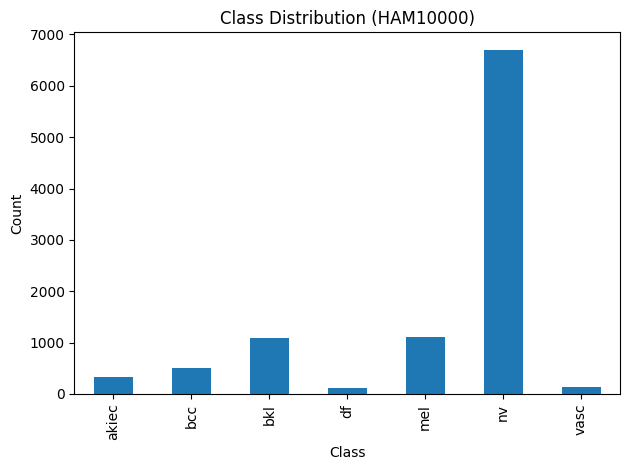

Saved: /content/outputs_ham10000/class_distribution.png


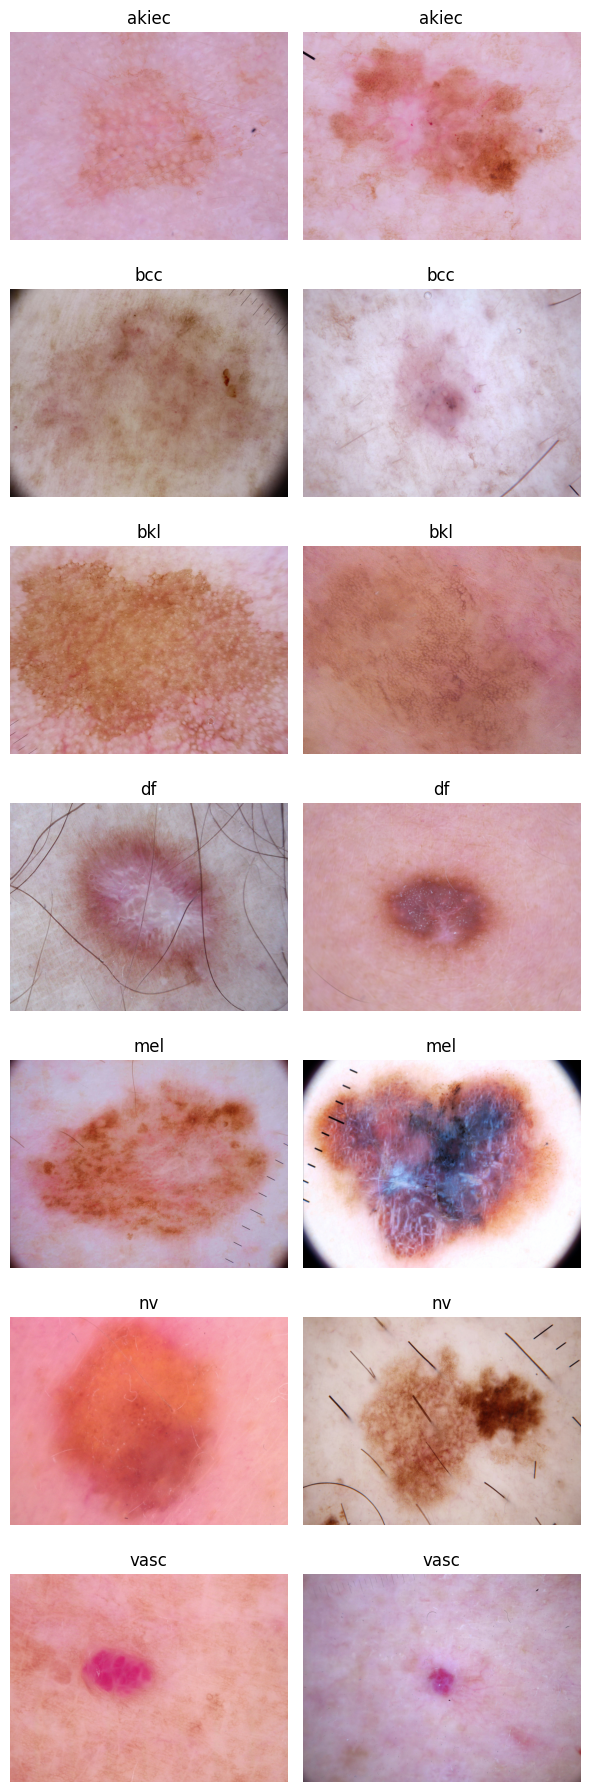

Saved: /content/outputs_ham10000/samples_grid.png


In [5]:
# 5) Data Audit: Class Distribution + Sample Grid

counts = df["dx"].value_counts().sort_index()
plt.figure()
counts.plot(kind="bar")
plt.title("Class Distribution (HAM10000)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
dist_path = Path(CONFIG["OUT_DIR"]) / "class_distribution.png"
plt.savefig(dist_path, dpi=150)
plt.show()

print("Saved:", dist_path)

def show_samples_per_class(df, n_per_class=2):
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class*3, len(classes)*2.6))
    if len(classes) == 1:
        axes = np.array([axes])

    for i, c in enumerate(classes):
        sub = df[df["dx"] == c].sample(min(n_per_class, (df["dx"] == c).sum()), random_state=CONFIG["seed"])
        for j in range(n_per_class):
            ax = axes[i, j] if n_per_class > 1 else axes[i]
            ax.axis("off")
            if j < len(sub):
                p = sub.iloc[j]["image_path"]
                img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(c)
    plt.tight_layout()
    grid_path = Path(CONFIG["OUT_DIR"]) / "samples_grid.png"
    plt.savefig(grid_path, dpi=150)
    plt.show()
    print("Saved:", grid_path)

show_samples_per_class(df, n_per_class=2)


## 6. Train / Validation / Test Split

We create:
- **test** split (held out, final evaluation)
- **validation** split (for model selection)
- **train** split (for fitting)

We use **stratified split** to preserve class proportions.

**Artifacts saved**
- `splits/train.csv`
- `splits/val.csv`
- `splits/test.csv`

---


In [6]:
# 6) Train/Val/Test Split (Stratified + Fixed Seed)

y = df["label"].values
strat = y if CONFIG["stratify"] else None

df_trainval, df_test = train_test_split(
    df,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["seed"],
    stratify=strat
)

y_trainval = df_trainval["label"].values
strat2 = y_trainval if CONFIG["stratify"] else None

df_train, df_val = train_test_split(
    df_trainval,
    test_size=CONFIG["val_size"],
    random_state=CONFIG["seed"],
    stratify=strat2
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Split sizes:", len(df_train), len(df_val), len(df_test))

splits_dir = Path(CONFIG["OUT_DIR"]) / "splits"
splits_dir.mkdir(parents=True, exist_ok=True)
df_train.to_csv(splits_dir / "train.csv", index=False)
df_val.to_csv(splits_dir / "val.csv", index=False)
df_test.to_csv(splits_dir / "test.csv", index=False)

print("Saved splits to:", splits_dir)


Split sizes: 7235 1277 1503
Saved splits to: /content/outputs_ham10000/splits


## 7. Augmentation Policies (Light vs Strong)

Augmentation helps generalization and reduces overfitting.

- **Light**: basic flips, small rotation, mild color jitter
- **Strong**: shift/scale/rotate + noise/blur + dropout (moderate)

**Important:** For pretrained backbones we normalize using ImageNet statistics.

---


In [7]:
# 7) Augmentations (Albumentations)

IMG_SIZE = CONFIG["img_size"]

def get_transforms(policy: str):
    if policy == "light":
        train_tfms = A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.Rotate(limit=30, p=0.5),
            A.ColorJitter(p=0.3),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2(),
        ])
    elif policy == "strong":
        train_tfms = A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=45, p=0.7),
            A.ColorJitter(p=0.5),
            A.GaussianBlur(p=0.2),
            A.GaussNoise(p=0.2),
            A.CoarseDropout(max_holes=8, max_height=24, max_width=24, p=0.3),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2(),
        ])
    else:
        raise ValueError("Unknown aug_policy. Use 'light' or 'strong'.")

    val_tfms = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])
    return train_tfms, val_tfms

train_tfms, val_tfms = get_transforms(CONFIG["aug_policy"])
print("Aug policy:", CONFIG["aug_policy"])


Aug policy: strong


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1034914199.py:25: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=24, max_width=24, p=0.3),


## 8. Dataset & DataLoaders

We define:
- `HamDataset`: reads image by path + returns tensor and label
- DataLoaders for train/val/test

Optional:
- **WeightedRandomSampler** (if `use_sampler=True`) to sample minority classes more often.

**Expected output**
- One batch shape: `[B, 3, 224, 224]`

---


In [8]:
# 8) Dataset & DataLoaders

class HamDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["image_path"]
        label = int(row["label"])

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms:
            img = self.transforms(image=img)["image"]

        return img, label

train_ds = HamDataset(df_train, transforms=train_tfms)
val_ds   = HamDataset(df_val, transforms=val_tfms)
test_ds  = HamDataset(df_test, transforms=val_tfms)

sampler = None
if CONFIG["use_sampler"]:
    class_counts = df_train["label"].value_counts().sort_index().values
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[df_train["label"].values]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=(sampler is None),
    sampler=sampler,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape, "Batch y:", yb.shape)


Batch X: torch.Size([32, 3, 224, 224]) Batch y: torch.Size([32])


## 9. Model (Pretrained Backbone via timm)

We use a pretrained model for strong baseline performance:
- `efficientnet_b0` (fast and strong)
- final head is automatically adapted to `num_classes=7`

**Output**
- Parameter count
- Backbone name

---


In [9]:
# 9) Model (timm pretrained)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(classes)

model = timm.create_model(
    CONFIG["backbone"],
    pretrained=CONFIG["pretrained"],
    num_classes=num_classes,
    drop_rate=CONFIG["dropout"]
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print("Backbone:", CONFIG["backbone"])
print("Params:", f"{n_params/1e6:.2f}M")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Backbone: efficientnet_b0
Params: 4.02M


## 10. Loss & Class Imbalance Strategy

Class imbalance is severe in HAM10000.
We support:
- `ce`: standard CrossEntropy (baseline)
- `weighted_ce`: CrossEntropy with class weights computed from train split
- `focal`: Focal Loss (hard examples focus)

**Recommendation**
Start with:
- `weighted_ce` + strong augmentations

---


In [10]:
# 10) Loss Functions (CE / Weighted CE / Focal)


def compute_class_weights(df_train, num_classes):
    counts = df_train["label"].value_counts().reindex(range(num_classes), fill_value=0).values.astype(np.float32)
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32, device=device)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = alpha

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce

        if self.alpha is not None:
            if isinstance(self.alpha, (float, int)):
                at = torch.full_like(targets, float(self.alpha), dtype=torch.float32, device=logits.device)
            else:
                at = self.alpha[targets]
            focal = at * focal

        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal

loss_type = CONFIG["loss_type"]

if loss_type == "ce":
    criterion = nn.CrossEntropyLoss()
elif loss_type == "weighted_ce":
    w = compute_class_weights(df_train, num_classes)
    print("Class weights:", w.detach().cpu().numpy())
    criterion = nn.CrossEntropyLoss(weight=w)
elif loss_type == "focal":
    alpha = CONFIG["focal_alpha"]
    if isinstance(alpha, list):
        alpha = torch.tensor(alpha, dtype=torch.float32, device=device)
    criterion = FocalLoss(gamma=CONFIG["focal_gamma"], alpha=alpha)
else:
    raise ValueError("loss_type must be 'ce', 'weighted_ce', or 'focal'.")

print("Loss:", loss_type)


Class weights: [ 4.37954     2.7784178   1.3017273  12.452668    1.2855366   0.21337147
 10.133053  ]
Loss: weighted_ce


## 11. Optimizer, Scheduler, Mixed Precision (AMP)

We use:
- AdamW (stable)
- Cosine Annealing LR scheduler
- AMP for faster training on GPU

---


In [11]:
# 11) Optimizer, Scheduler, AMP

optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["amp"])
print("AMP:", CONFIG["amp"])


AMP: True


/tmp/ipython-input-29628487.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["amp"])


## 12. Training & Evaluation Helpers

We define:
- `train_one_epoch()`
- `evaluate()` returning loss + Macro-F1 + Balanced Accuracy
- helper functions to compute metrics from logits

**Key metric**: **Macro-F1** (best for imbalanced multi-class)

---


In [12]:
# 12) Helper functions: train / eval + metrics

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_logits = []
    all_targets = []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        all_logits.append(logits.detach().cpu())
        all_targets.append(yb.detach().cpu())
    return torch.cat(all_logits, 0), torch.cat(all_targets, 0)

def macro_f1_from_logits(logits, targets):
    preds = logits.argmax(dim=1).numpy()
    t = targets.numpy()
    return f1_score(t, preds, average="macro")

def balanced_acc_from_logits(logits, targets):
    preds = logits.argmax(dim=1).numpy()
    t = targets.numpy()
    return balanced_accuracy_score(t, preds)

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0

    for xb, yb in tqdm(loader, desc="Train", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=CONFIG["amp"]):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * xb.size(0)

    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    logits, targets = predict_all(model, loader)
    loss = nn.functional.cross_entropy(logits, targets, reduction="mean").item()
    mf1 = macro_f1_from_logits(logits, targets)
    bacc = balanced_acc_from_logits(logits, targets)
    return loss, mf1, bacc, logits, targets


## 13. Training Loop (Best Checkpoint + Early Stopping)

**What happens here**
- Train epoch
- Evaluate on validation
- Save **best checkpoint** by `val_macro_f1`
- Early stopping if no improvement for `patience` epochs
- Save `history.csv`

**Artifacts**
- `checkpoints/best_model.pt`
- `history.csv`

---


In [13]:
# 13) Training Loop + Best Checkpoint + Early Stopping

out_dir = Path(CONFIG["OUT_DIR"])
ckpt_dir = out_dir / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)

history = []
best_metric = -1.0
best_path = ckpt_dir / "best_model.pt"
patience = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_mf1, val_bacc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_macro_f1": val_mf1,
        "val_balanced_acc": val_bacc,
        "lr": optimizer.param_groups[0]["lr"],
        "time_sec": round(time.time() - t0, 1)
    }
    history.append(row)
    print(row)

    metric = val_mf1
    if metric > best_metric:
        best_metric = metric
        patience = 0
        torch.save({
            "model_state": model.state_dict(),
            "config": CONFIG,
            "classes": classes,
            "class_to_idx": class_to_idx,
            "best_val_macro_f1": best_metric,
            "epoch": epoch
        }, best_path)
        print(f" New best model saved: {best_path} | best_val_macro_f1={best_metric:.4f}")
    else:
        patience += 1
        if patience >= CONFIG["early_stopping_patience"]:
            print(" Early stopping triggered.")
            break

hist_df = pd.DataFrame(history)
hist_csv = out_dir / "history.csv"
hist_df.to_csv(hist_csv, index=False)
print("Saved:", hist_csv)


Train:   0%|          | 0/227 [00:00<?, ?it/s]/tmp/ipython-input-786223213.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["amp"]):


{'epoch': 1, 'train_loss': 2.385258962157354, 'val_loss': 1.4660134315490723, 'val_macro_f1': 0.4326437944808501, 'val_balanced_acc': np.float64(0.5267931216888116), 'lr': 0.0002967221401100708, 'time_sec': 100.3}
 New best model saved: /content/outputs_ham10000/checkpoints/best_model.pt | best_val_macro_f1=0.4326


Train:   0%|          | 0/227 [00:00<?, ?it/s]/tmp/ipython-input-786223213.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["amp"]):


{'epoch': 2, 'train_loss': 1.607416740383209, 'val_loss': 1.0603948831558228, 'val_macro_f1': 0.4613172093893527, 'val_balanced_acc': np.float64(0.6697684856003187), 'lr': 0.0002870318186463901, 'time_sec': 75.1}
 New best model saved: /content/outputs_ham10000/checkpoints/best_model.pt | best_val_macro_f1=0.4613


Train:   0%|          | 0/227 [00:00<?, ?it/s]/tmp/ipython-input-786223213.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["amp"]):


...

{'epoch': 13, 'train_loss': 0.7227062098141284, 'val_loss': 0.5287562608718872, 'val_macro_f1': 0.7464223491257392, 'val_balanced_acc': np.float64(0.8097026927324503), 'lr': 1.2968181353609857e-05, 'time_sec': 73.9}
 New best model saved: /content/outputs_ham10000/checkpoints/best_model.pt | best_val_macro_f1=0.7464


Train:   0%|          | 0/227 [00:00<?, ?it/s]/tmp/ipython-input-786223213.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["amp"]):


{'epoch': 14, 'train_loss': 0.7046099924761094, 'val_loss': 0.5095946788787842, 'val_macro_f1': 0.7336356848624087, 'val_balanced_acc': np.float64(0.8098209590426048), 'lr': 3.2778598899291478e-06, 'time_sec': 73.2}


Train:   0%|          | 0/227 [00:00<?, ?it/s]/tmp/ipython-input-786223213.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["amp"]):


{'epoch': 15, 'train_loss': 0.6790237944786847, 'val_loss': 0.48795586824417114, 'val_macro_f1': 0.7527037246116943, 'val_balanced_acc': np.float64(0.800716618973529), 'lr': 0.0, 'time_sec': 74.2}
 New best model saved: /content/outputs_ham10000/checkpoints/best_model.pt | best_val_macro_f1=0.7527
Saved: /content/outputs_ham10000/history.csv


## 14. Final Test Evaluation (using best checkpoint)

We evaluate on the held-out test set:
- Test Macro-F1
- Balanced Accuracy
- Classification report

**Artifacts**
- `metrics.json`
- `classification_report.txt`

---


In [14]:
# 14) Test Evaluation (Load best checkpoint)

ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])

test_loss, test_mf1, test_bacc, test_logits, test_targets = evaluate(model, test_loader)
print("TEST loss:", round(test_loss, 4))
print("TEST macro F1:", round(test_mf1, 4))
print("TEST balanced acc:", round(test_bacc, 4))

metrics = {
    "test_loss": float(test_loss),
    "test_macro_f1": float(test_mf1),
    "test_balanced_acc": float(test_bacc),
    "best_val_macro_f1": float(ckpt["best_val_macro_f1"]),
    "best_epoch": int(ckpt["epoch"]),
}
metrics_path = out_dir / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved:", metrics_path)

preds = test_logits.argmax(dim=1).numpy()
t = test_targets.numpy()
rep = classification_report(t, preds, target_names=[idx_to_class[i] for i in range(num_classes)])
print(rep)

rep_path = out_dir / "classification_report.txt"
with open(rep_path, "w") as f:
    f.write(rep)
print("Saved:", rep_path)


TEST loss: 0.5016
TEST macro F1: 0.7385
TEST balanced acc: 0.797
Saved: /content/outputs_ham10000/metrics.json
              precision    recall  f1-score   support

       akiec       0.67      0.80      0.73        49
         bcc       0.78      0.69      0.73        77
         bkl       0.61      0.73      0.66       165
          df       0.70      0.94      0.80        17
         mel       0.49      0.67      0.57       167
          nv       0.95      0.85      0.89      1006
        vasc       0.69      0.91      0.78        22

    accuracy                           0.81      1503
   macro avg       0.70      0.80      0.74      1503
weighted avg       0.83      0.81      0.82      1503

Saved: /content/outputs_ham10000/classification_report.txt


## 15. Confusion Matrix

A confusion matrix provides a class-by-class view of errors.
This is essential for medical imaging tasks to understand which classes are confused.

**Artifact**
- `confusion_matrix.png`

---


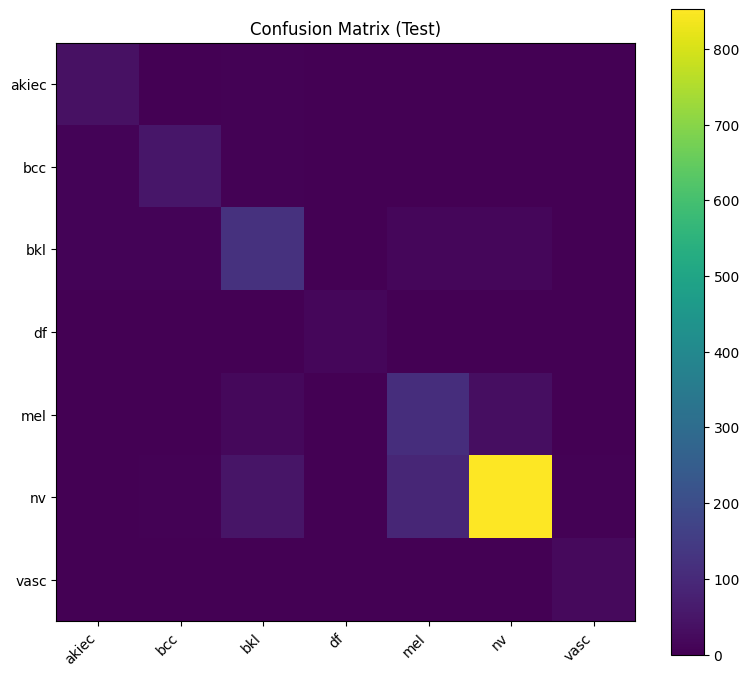

Saved: /content/outputs_ham10000/confusion_matrix.png


In [15]:
# 15) Confusion Matrix Plot

cm = confusion_matrix(t, preds, labels=list(range(num_classes)))

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.xticks(range(num_classes), [idx_to_class[i] for i in range(num_classes)], rotation=45, ha="right")
plt.yticks(range(num_classes), [idx_to_class[i] for i in range(num_classes)])
plt.colorbar()
plt.tight_layout()

cm_path = out_dir / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print("Saved:", cm_path)


## 16. Error Analysis (Misclassifications)

We visualize a grid of misclassified images with:
- True label
- Predicted label

**Artifact**
- `misclassifications_grid.png`

---


Misclassifications: 291


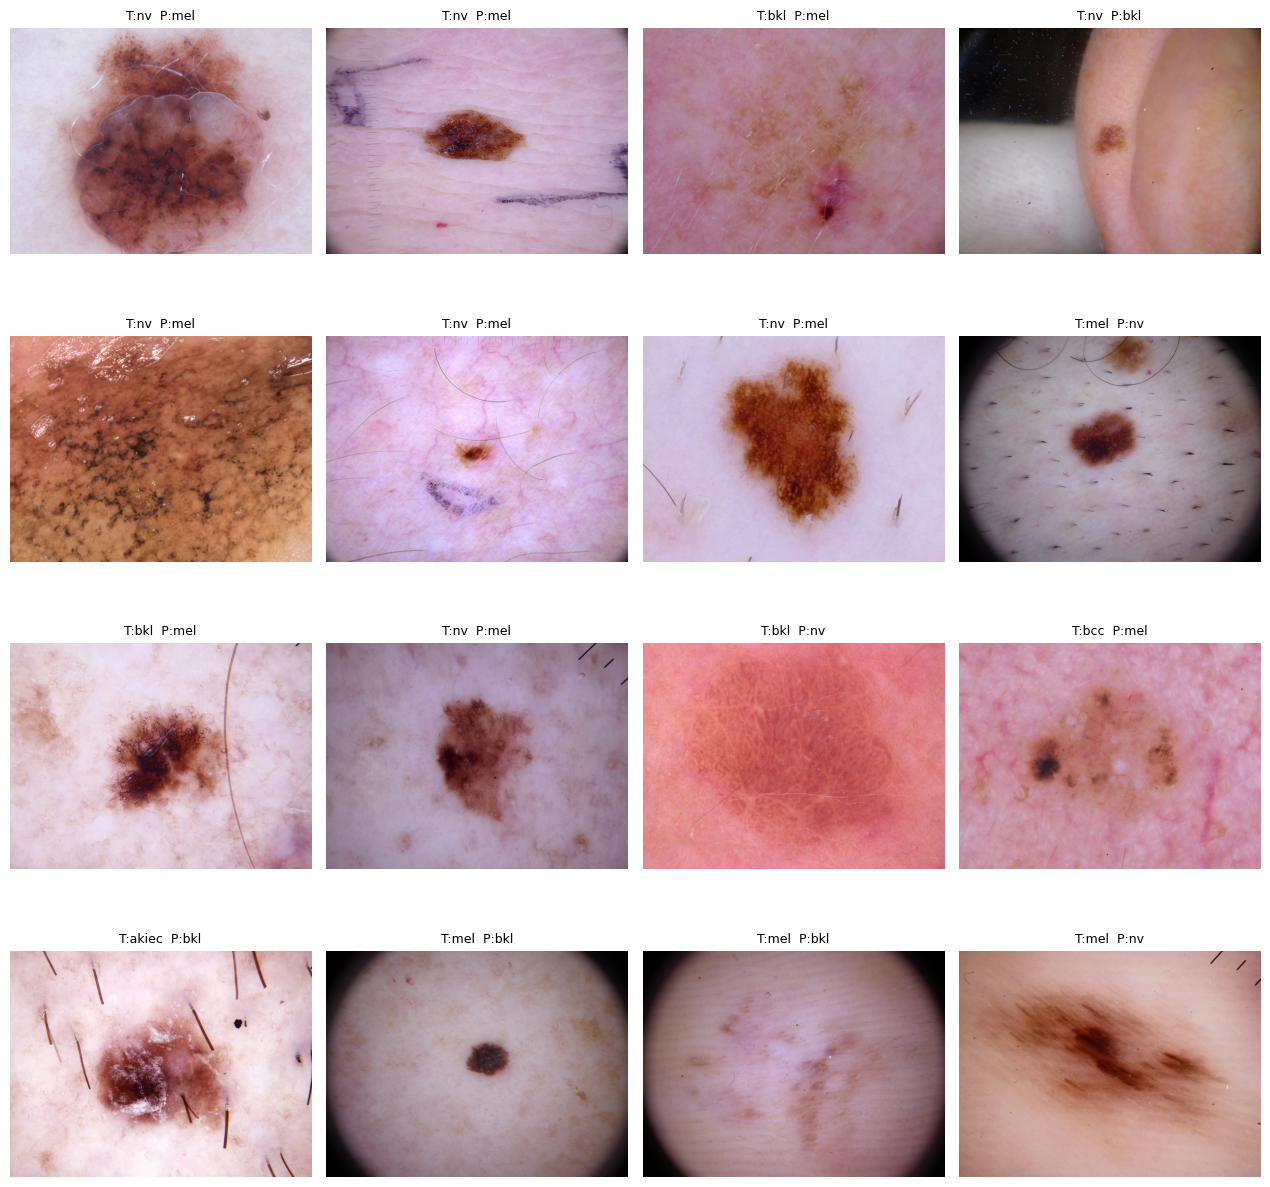

Saved: /content/outputs_ham10000/misclassifications_grid.png


In [16]:
# 16) Error Analysis: Misclassifications Grid

df_test_vis = df_test.copy()
df_test_vis["pred"] = preds
df_test_vis["true"] = t
df_mis = df_test_vis[df_test_vis["pred"] != df_test_vis["true"]].copy()

print("Misclassifications:", len(df_mis))

def show_misclassified(df_mis, n=16):
    n = min(n, len(df_mis))
    if n == 0:
        print("No misclassifications to display.")
        return
    sample = df_mis.sample(n, random_state=CONFIG["seed"])
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols*3.2, rows*3.2))
    for i, (_, r) in enumerate(sample.iterrows()):
        plt.subplot(rows, cols, i+1)
        img = cv2.cvtColor(cv2.imread(r["image_path"]), cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"T:{idx_to_class[r['true']]}  P:{idx_to_class[r['pred']]}", fontsize=9)
    plt.tight_layout()
    outp = out_dir / "misclassifications_grid.png"
    plt.savefig(outp, dpi=150)
    plt.show()
    print("Saved:", outp)

show_misclassified(df_mis, n=16)


## 17. (Bonus) Explainability with Grad-CAM

Grad-CAM highlights the regions that most influenced the decision.
We generate overlays on a few test samples.

**Artifact**
- `gradcam_examples.png`

---


Using target layer: conv_head


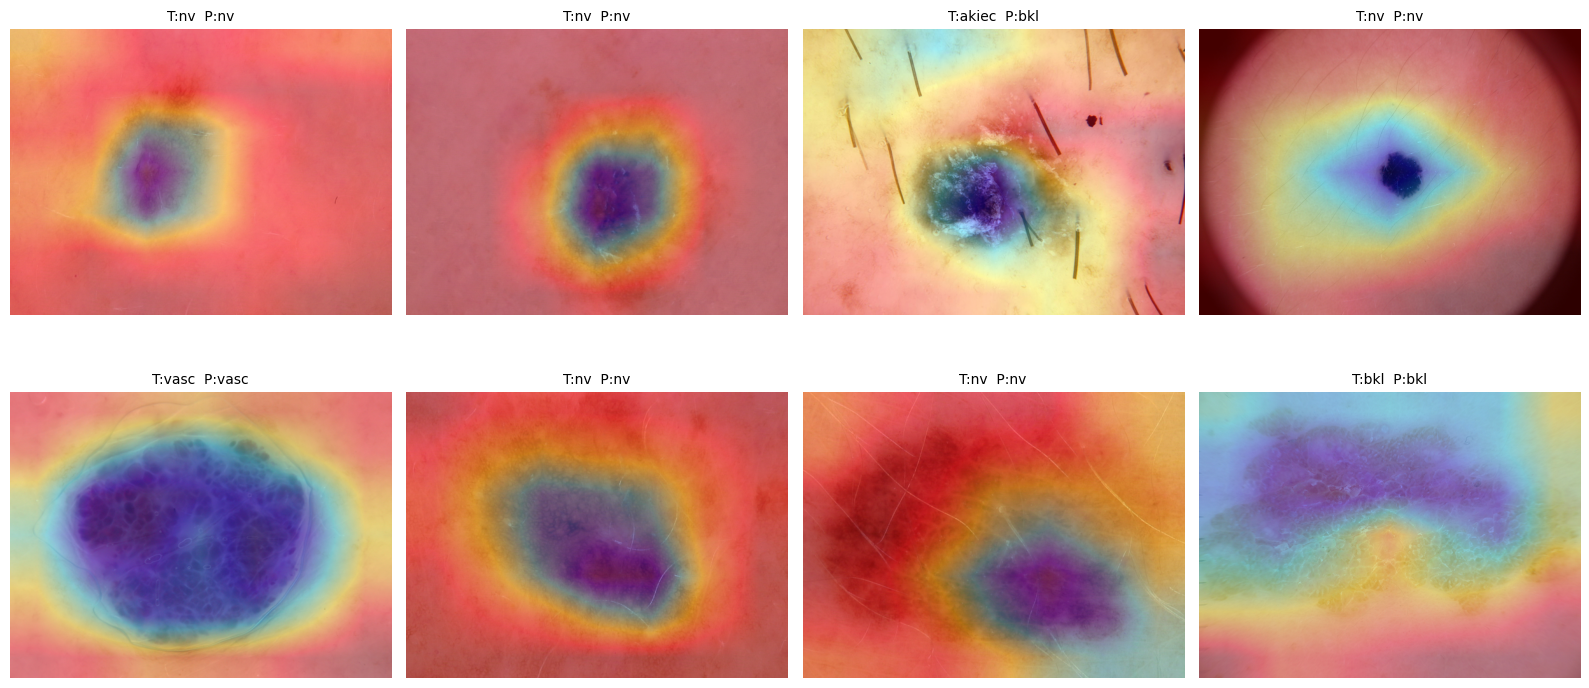

Saved: /content/outputs_ham10000/gradcam_examples.png


In [17]:
# ============================================================
# 17) (Bonus) Grad-CAM (Simple Implementation)
# ============================================================

from typing import Optional

class GradCAM:
    def __init__(self, model, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove(self):
        for h in self.hook_handles:
            h.remove()

    def __call__(self, x, class_idx: Optional[int] = None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        score = logits[:, class_idx].sum()
        score.backward()

        grads = self.gradients
        acts = self.activations
        weights = grads.mean(dim=(2,3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam, class_idx

target_layer = None
for name, m in reversed(list(model.named_modules())):
    if isinstance(m, nn.Conv2d):
        target_layer = m
        print("Using target layer:", name)
        break

if target_layer is None:
    print("Could not find Conv2d layer for Grad-CAM. Skipping.")
else:
    gradcam = GradCAM(model, target_layer)

    n_show = 8
    sample = df_test.sample(min(n_show, len(df_test)), random_state=CONFIG["seed"])

    plt.figure(figsize=(16, 8))
    for i, (_, r) in enumerate(sample.iterrows()):
        img = cv2.cvtColor(cv2.imread(r["image_path"]), cv2.COLOR_BGR2RGB)
        x = val_tfms(image=img)["image"].unsqueeze(0).to(device)

        cam, _ = gradcam(x)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

        heat = (cam * 255).astype(np.uint8)
        heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(img, 0.65, heat, 0.35, 0)

        with torch.no_grad():
            logits = model(x)
            pred = logits.argmax(dim=1).item()

        plt.subplot(2, 4, i+1)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title(f"T:{idx_to_class[r['label']]}  P:{idx_to_class[pred]}", fontsize=10)

    plt.tight_layout()
    gc_path = out_dir / "gradcam_examples.png"
    plt.savefig(gc_path, dpi=150)
    plt.show()
    print("Saved:", gc_path)

    gradcam.remove()


## 18. Export Artifacts

We zip the `OUT_DIR` folder so you can:
- download it
- move it to Drive
- attach it to your GitHub release

**Output**
- `/content/ham10000_outputs.zip`

---


In [18]:
# 18) Export Artifacts (Zip outputs)

zip_name = "/content/ham10000_outputs.zip"
!rm -f {zip_name}
!zip -r -q {zip_name} {CONFIG["OUT_DIR"]}
print(" Exported:", zip_name)

# Optional: mount drive and copy
# from google.colab import drive
# drive.mount('/content/drive')
# !cp {zip_name} /content/drive/MyDrive/


 Exported: /content/ham10000_outputs.zip
